# Phase 3 Step 4 — Final Model-Family Resolution

This deliberately narrow experiment evaluates exactly three predeclared `ExtraTreesClassifier` candidates against the frozen heuristic and HGB-1. The 16 features, 28-day no-return target, eligibility, and April–October development cohorts are unchanged. **November lockbox outcomes remain untouched.**

## Why one final challenger

HGB-1 narrowly missed the heuristic by 0.34% relative PR-AUC while improving ROC-AUC and calibration diagnostics. Extra Trees supplies one final materially different sklearn tree ensemble. Heuristic performance is a legitimate outcome: complexity is not forced when a learned model does not meaningfully win. This experiment closes family search, so no feature search or further classifier family follows merely to chase metrics.

In [1]:
from pathlib import Path
import io,sys,time,joblib
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
import numpy as np,pandas as pd,pyreadr,matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from marketmind.return_risk.cohorts import build_labeled_cohort
from marketmind.return_risk.features import build_candidate_features,baseline_features,make_logistic_preprocessor,BASELINE_FEATURE_ORDER
from marketmind.return_risk.models import (EXTRA_TREES_CANDIDATE_PARAMETERS,TRAINING_SNAPSHOTS,VALIDATION_SNAPSHOTS,LOCKBOX_SNAPSHOT,fit_extra_trees_candidate,fit_hgb_candidate)
from marketmind.return_risk.evaluation import score_metrics,capacity_metrics,calibration_bins,clustered_bootstrap_auc
pd.set_option('display.max_columns',40)
RAW=ROOT/'data'/'raw'/'complete_journey';ART=ROOT/'reports'/'return_risk'/'artifacts';FIG=ROOT/'reports'/'return_risk'/'figures';ART.mkdir(parents=True,exist_ok=True);FIG.mkdir(parents=True,exist_ok=True)
assert tuple(EXTRA_TREES_CANDIDATE_PARAMETERS)==('ET-1','ET-2','ET-3')
assert LOCKBOX_SNAPSHOT not in (*TRAINING_SNAPSHOTS,*VALIDATION_SNAPSHOTS)

## Frozen problem, features, and candidates

Positive class 1 means zero distinct baskets in `(T,T+28d]`, not churn. Extra Trees receives exact raw feature values, without scaling. All candidates are unweighted and deterministic.

In [2]:
pd.DataFrame(EXTRA_TREES_CANDIDATE_PARAMETERS).T

,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,n_jobs,random_state
ET-1,300,None,5,sqrt,None,-1,42
ET-2,300,12,10,sqrt,None,-1,42
ET-3,300.0,12.0,5.0,0.8,NaN,-1.0,42.0


## Training setup

Build only April–October. Each Extra Trees candidate is fit once on April–August and used unchanged for both validation months. Missingness is audited without validation-derived imputation.

In [3]:
transactions=pyreadr.read_r(str(RAW/'transactions.rds'))[None];products=pyreadr.read_r(str(RAW/'products.rda'))['products'];transactions.transaction_timestamp=pd.to_datetime(transactions.transaction_timestamp)
frames=[]
for snapshot in (*TRAINING_SNAPSHOTS,*VALIDATION_SNAPSHOTS):
    X=baseline_features(build_candidate_features(transactions,products,snapshot));y=build_labeled_cohort(transactions,snapshot,28,'2017-12-31 23:59:59')[['return_risk_target']]
    z=X.join(y,validate='one_to_one').reset_index();z['snapshot_at']=snapshot;frames.append(z)
data=pd.concat(frames,ignore_index=True);assert data.snapshot_at.max()==VALIDATION_SNAPSHOTS[-1]
train=data[data.snapshot_at.isin(TRAINING_SNAPSHOTS)].copy();validation=data[data.snapshot_at.isin(VALIDATION_SNAPSHOTS)].copy();X_train=train.loc[:,BASELINE_FEATURE_ORDER];y_train=train.return_risk_target;X_valid=validation.loc[:,BASELINE_FEATURE_ORDER];y_valid=validation.return_risk_target
assert len(train)==10223 and len(validation)==4529 and X_train.isna().sum().sum()==0 and X_valid.isna().sum().sum()==0

## Extra Trees results and computational profile

In [4]:
models={};scores={};rows=[];compute=[]
for name in EXTRA_TREES_CANDIDATE_PARAMETERS:
    started=time.perf_counter();model=fit_extra_trees_candidate(name,X_train,y_train,train.snapshot_at);fit_s=time.perf_counter()-started
    started=time.perf_counter();score=model.predict_proba(X_valid)[:,1];predict_s=time.perf_counter()-started
    buffer=io.BytesIO();joblib.dump(model,buffer);size=len(buffer.getvalue())/1024;models[name]=model;scores[name]=score;compute.append({'candidate':name,'fit_seconds':fit_s,'prediction_seconds':predict_s,'serialized_kib':size})
    for cohort,date in [('September','2017-09-30'),('October','2017-10-31'),('Pooled',None)]:
        mask=np.ones(len(validation),bool) if date is None else validation.snapshot_at.dt.date==pd.Timestamp(date).date();rows.append({'candidate':name,'cohort':cohort,**score_metrics(y_valid[mask],score[mask])})
metrics=pd.DataFrame(rows);compute=pd.DataFrame(compute);metrics.to_csv(ART/'extra_trees_metrics.csv',index=False);compute.to_csv(ART/'extra_trees_compute.csv',index=False);display(metrics.drop(columns=['confusion_matrix','precision_at_0_5','recall_at_0_5','f1_at_0_5']).round(5));display(compute.round(4))

,candidate,cohort,n,prevalence,pr_auc,roc_auc,log_loss,brier
0,ET-1,September,2247,0.13796,0.49065,0.86487,0.28684,0.08909
1,ET-1,October,2282,0.13804,0.47645,0.85346,0.29514,0.09171
2,ET-1,Pooled,4529,0.13800,0.48165,0.85916,0.29102,0.09041
3,ET-2,September,2247,0.13796,0.49894,0.86466,0.28944,0.09007
4,ET-2,October,2282,0.13804,0.46951,0.85061,0.29934,0.09315
5,ET-2,Pooled,4529,0.13800,0.48265,0.85760,0.29443,0.09163
6,ET-3,September,2247,0.13796,0.47862,0.86237,0.29004,0.08982
7,ET-3,October,2282,0.13804,0.46955,0.85205,0.29597,0.09212
8,ET-3,Pooled,4529,0.13800,0.47149,0.85714,0.29303,0.09098


,candidate,fit_seconds,prediction_seconds,serialized_kib
0,ET-1,0.4211,0.0498,32601.5557
1,ET-2,0.2836,0.0374,8397.1650
2,ET-3,0.3906,0.0390,18750.7744


## Predeclared selection policy

Extra Trees is eligible only if pooled PR-AUC exceeds 0.4688 without severe temporal instability. Learned candidates within 1% relative PR-AUC are resolved using stability, calibration, size, inference, and production simplicity. If no learned candidate meaningfully exceeds the heuristic, the heuristic remains the ranking policy and family search closes.

In [5]:
pooled=metrics[metrics.cohort.eq('Pooled')].set_index('candidate');best_et=pooled.pr_auc.idxmax();benchmark=0.46878013835124294
selection=pd.Series({'best_extra_trees':best_et,'pooled_pr_auc':pooled.loc[best_et,'pr_auc'],'absolute_vs_heuristic':pooled.loc[best_et,'pr_auc']-benchmark,'relative_vs_heuristic_pct':(pooled.loc[best_et,'pr_auc']/benchmark-1)*100,'eligible':pooled.loc[best_et,'pr_auc']>benchmark});selection

best_extra_trees                 ET-2
pooled_pr_auc                0.482651
absolute_vs_heuristic        0.013871
relative_vs_heuristic_pct    2.958871
eligible                         True
dtype: object

## Frozen comparator reconstruction

HGB-1, Logistic, and the heuristic are reconstructed only to compare rankings/calibration on the same validation rows. No HGB tuning or additional family is introduced.

In [6]:
hgb=fit_hgb_candidate('HGB-1',X_train,y_train,train.snapshot_at);hgb_score=hgb.predict_proba(X_valid)[:,1]
logistic=Pipeline([('preprocess',make_logistic_preprocessor()),('model',LogisticRegression(class_weight=None,solver='lbfgs',max_iter=2000,random_state=42))]).fit(X_train,y_train);logistic_score=logistic.predict_proba(X_valid)[:,1]
lf=np.log1p(train.basket_frequency_lifetime);rm,rs=train.recency_days.mean(),train.recency_days.std(ddof=0);fm,fs=lf.mean(),lf.std(ddof=0);heuristic_score=expit((validation.recency_days-rm)/rs-(np.log1p(validation.basket_frequency_lifetime)-fm)/fs)
comparison=pd.DataFrame({name:score_metrics(y_valid,score) for name,score in [('Heuristic',heuristic_score),('HGB-1',hgb_score),(best_et,scores[best_et]),('Logistic',logistic_score)]}).T;display(comparison.drop(columns='confusion_matrix').round(5))

,n,prevalence,pr_auc,roc_auc,log_loss,brier,precision_at_0_5,recall_at_0_5,f1_at_0_5
Heuristic,4529,0.138,0.46878,0.845946,0.660606,0.193875,0.321474,0.8096,0.460209
HGB-1,4529,0.138,0.467195,0.857353,0.293189,0.091328,0.532164,0.2912,0.376422
ET-2,4529,0.138,0.482651,0.857602,0.29443,0.091625,0.703297,0.1024,0.178771
Logistic,4529,0.138,0.458618,0.850756,0.297965,0.092861,0.542857,0.2432,0.335912


## Household-clustered bootstrap

In [7]:
intervals=clustered_bootstrap_auc(validation.assign(score=scores[best_et]),household_column='household_id',target_column='return_risk_target',score_column='score',n_bootstrap=300);intervals

{'pr_auc_95ci': (0.43126474851072777, 0.5261465036485646),
 'roc_auc_95ci': (0.8407808023234146, 0.871448529267067)}

## Capacity metrics

Top fractions operate on household-snapshot prediction rows. They are capacity simulations, not thresholds or business impact.

In [8]:
caps=[]
for name,score in [('Heuristic',heuristic_score),('HGB-1',hgb_score),(best_et,scores[best_et])]:caps.append(capacity_metrics(y_valid,score).assign(model=name))
capacity=pd.concat(caps,ignore_index=True);capacity.to_csv(ART/'final_capacity_comparison.csv',index=False);display(capacity.round(4))

,capacity,selected,positives_captured,precision,recall,model
0,0.05,227,135,0.5947,0.2160,Heuristic
1,0.10,453,245,0.5408,0.3920,Heuristic
2,0.20,906,379,0.4183,0.6064,Heuristic
3,0.05,227,128,0.5639,0.2048,HGB-1
4,0.10,453,236,0.5210,0.3776,HGB-1
5,0.20,906,389,0.4294,0.6224,HGB-1
6,0.05,227,134,0.5903,0.2144,ET-2
7,0.10,453,243,0.5364,0.3888,ET-2
8,0.20,906,385,0.4249,0.6160,ET-2


## Ranking agreement

Overlap uses the prediction entity `(household_id,snapshot_at)`. Deterministic score/index sorting identifies top 5/10/20% sets; intersection and Jaccard quantify whether policies target the same cases.

In [9]:
keys=pd.Series(list(zip(validation.household_id,validation.snapshot_at)),index=np.arange(len(validation)))
score_map={'Heuristic':np.asarray(heuristic_score),'HGB-1':hgb_score,best_et:scores[best_et]}
overlap=[]
for fraction in (.05,.10,.20):
    n=int(np.ceil(len(validation)*fraction));sets={name:set(keys.iloc[np.lexsort((np.arange(len(score)),-score))[:n]]) for name,score in score_map.items()}
    for left,right in [('Heuristic','HGB-1'),('Heuristic',best_et),('HGB-1',best_et)]:
        inter=len(sets[left]&sets[right]);overlap.append({'capacity':fraction,'left':left,'right':right,'selected_each':n,'intersection':inter,'jaccard':inter/len(sets[left]|sets[right])})
overlap=pd.DataFrame(overlap);overlap.to_csv(ART/'ranking_overlap.csv',index=False);display(overlap.round(4))

,capacity,left,right,selected_each,intersection,jaccard
0,0.05,Heuristic,HGB-1,227,153,0.5083
1,0.05,Heuristic,ET-2,227,191,0.7262
2,0.05,HGB-1,ET-2,227,168,0.5874
3,0.10,Heuristic,HGB-1,453,343,0.6092
4,0.10,Heuristic,ET-2,453,373,0.6998
5,0.10,HGB-1,ET-2,453,374,0.7030
6,0.20,Heuristic,HGB-1,906,733,0.6793
7,0.20,Heuristic,ET-2,906,789,0.7713
8,0.20,HGB-1,ET-2,906,806,0.8012


## Calibration diagnostics

The heuristic is excluded because it is a ranking score, not a probability model. Extra Trees, HGB-1, and Logistic remain uncalibrated; no calibrator is fit.

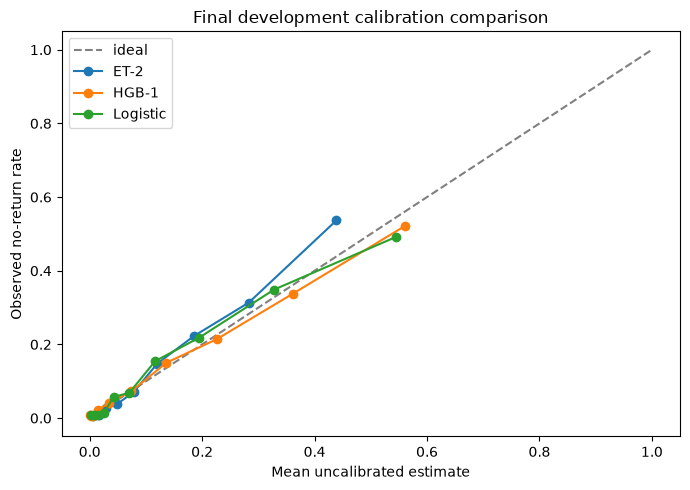

,mean_score,observed_rate,model
0,0.0053,0.0066,ET-2
1,0.0099,0.0088,ET-2
2,0.0163,0.0088,ET-2
3,0.0287,0.0265,ET-2
4,0.0482,0.0375,ET-2
5,0.0782,0.0708,ET-2
6,0.1202,0.1479,ET-2
7,0.1856,0.2230,ET-2
8,0.2829,0.3135,ET-2
9,0.4386,0.5364,ET-2


In [10]:
cal=[];fig,ax=plt.subplots(figsize=(7,5));ax.plot([0,1],[0,1],'--',color='grey',label='ideal')
for name,score in [(best_et,scores[best_et]),('HGB-1',hgb_score),('Logistic',logistic_score)]:
    bins=calibration_bins(y_valid,score,10).assign(model=name);cal.append(bins);ax.plot(bins.mean_score,bins.observed_rate,marker='o',label=name)
ax.set(xlabel='Mean uncalibrated estimate',ylabel='Observed no-return rate',title='Final development calibration comparison');ax.legend();fig.tight_layout();fig.savefig(FIG/'final_model_calibration.png',dpi=160);plt.show();calibration=pd.concat(cal);calibration.to_csv(ART/'final_model_calibration_bins.csv',index=False);display(calibration.round(4))

## Error analysis

The 0.5 cutoff is diagnostic only. Aggregate profiles contain no household IDs. Cross-model transitions test whether Extra Trees resolves HGB’s partially active false negatives.

In [11]:
profiles=[];predictions={best_et:(scores[best_et]>=.5).astype(int),'HGB-1':(hgb_score>=.5).astype(int)}
for name,pred in predictions.items():
    e=validation.copy();e['score']=score_map[name];e['prediction']=pred;e['error_type']=np.select([(e.return_risk_target.eq(1)&e.prediction.eq(1)),(e.return_risk_target.eq(0)&e.prediction.eq(1)),(e.return_risk_target.eq(0)&e.prediction.eq(0))],['TP','FP','TN'],default='FN');p=e.groupby('error_type')[list(BASELINE_FEATURE_ORDER)+['score']].median().reset_index();p['model']=name;profiles.append(p)
profiles=pd.concat(profiles);profiles.to_csv(ART/'final_error_profiles.csv',index=False);display(profiles.round(3))
hgb_fn=(y_valid.to_numpy()==1)&(predictions['HGB-1']==0);et_fn=(y_valid.to_numpy()==1)&(predictions[best_et]==0);transitions=pd.Series({'HGB_false_negatives':int(hgb_fn.sum()),'ET_false_negatives':int(et_fn.sum()),'HGB_FN_recovered_by_ET':int((hgb_fn&(predictions[best_et]==1)).sum()),'ET_FN_recovered_by_HGB':int((et_fn&(predictions['HGB-1']==1)).sum())});transitions

,error_type,recency_days,basket_frequency_lifetime,monetary_lifetime,average_basket_value,baskets_last_7d,baskets_last_28d,spend_last_28d,median_days_between_baskets,std_days_between_baskets,active_span_days,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,baskets_28d_change,spend_28d_change,score,model
0,FN,20.0,16.0,406.760,24.037,0.0,1.0,8.710,8.976,15.469,238.0,8.0,0.344,0.153,0.000,0.0,0.000,0.259,ET-2
1,FP,121.0,7.0,123.300,16.866,0.0,0.0,0.000,17.408,24.898,149.0,5.0,0.423,0.090,0.000,0.0,0.000,0.551,ET-2
2,TN,4.0,43.0,1234.980,27.498,1.0,4.0,113.590,4.417,6.097,269.0,11.0,0.334,0.150,0.031,0.0,0.000,0.043,ET-2
3,TP,125.5,7.0,149.480,19.617,0.0,0.0,0.000,11.068,20.429,125.5,5.0,0.412,0.127,0.000,0.0,0.000,0.538,ET-2
0,FN,13.0,17.0,439.070,24.641,0.0,1.0,20.300,8.205,14.187,249.0,9.0,0.344,0.155,0.000,0.0,0.000,0.259,HGB-1
1,FP,65.0,9.0,188.495,18.884,0.0,0.0,0.000,15.412,22.695,211.5,7.0,0.362,0.132,0.000,0.0,0.000,0.562,HGB-1
2,TN,3.0,45.0,1288.320,27.817,1.0,4.0,120.505,4.197,5.918,269.0,11.0,0.334,0.150,0.032,0.0,0.495,0.025,HGB-1
3,TP,75.0,8.0,193.590,20.478,0.0,0.0,0.000,13.006,20.882,185.0,7.0,0.384,0.141,0.000,0.0,0.000,0.574,HGB-1


HGB_false_negatives       443
ET_false_negatives        561
HGB_FN_recovered_by_ET      2
ET_FN_recovered_by_HGB    120
dtype: int64

## Computational comparison

Extra Trees and HGB sizes are in-memory joblib estimates, not production artifacts. The heuristic requires only four training summary values and arithmetic, so its artifact/inference cost is effectively negligible relative to either ensemble.

In [12]:
def profile_model(name,model,score):
    b=io.BytesIO();joblib.dump(model,b);started=time.perf_counter();model.predict_proba(X_valid)[:,1];return {'model':name,'prediction_seconds':time.perf_counter()-started,'serialized_kib':len(b.getvalue())/1024}
deployment=pd.DataFrame([{'model':'Heuristic','prediction_seconds':np.nan,'serialized_kib':0.1},profile_model('HGB-1',hgb,hgb_score),profile_model(best_et,models[best_et],scores[best_et])]);display(deployment.round(4))

,model,prediction_seconds,serialized_kib
0,Heuristic,NaN,0.1000
1,HGB-1,0.0085,290.5625
2,ET-2,0.0418,8397.1650


## Final model-family decision and output semantics

Apply the frozen gate exactly. If no learned model meaningfully exceeds heuristic PR-AUC, the recency–frequency heuristic becomes the final ranking approach for this modeling cycle. Its output is a **risk ranking score**, never a probability, confidence, or calibrated risk probability. HGB-1 may remain a learned research reference. No threshold or calibration is frozen.

## Limitations and next step

This short grocery-household panel has repeated observations and limited seasonality. Development metrics do not imply causal drivers or business impact. Family search closes after this experiment. The next authorized step should address ranking-policy operationalization and capacity/threshold governance without accessing November until all decisions are frozen.